# Config-Driven DKN Training

This notebook trains `GraphKalmanProcess` on the distance/angle constant-velocity scenario using a single `config_val` dictionary. It previews generated trajectories for each training run and saves both model weights and a matching JSON config file for later loading.

In [32]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from pytorch_lightning.loggers import CSVLogger
from torch_geometric.loader import DataLoader

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
importlib.reload(constant_velocity_scenario_module)

from utils.DistributedKalmanData import GraphDataset
from utils.DistributedKalmanNet import GraphKalmanProcess
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    create_distance_based_graph,
    get_trainer_accelerator,
    load_config,
    plot_generated_trajectories,
    plot_learning_curve,
    save_config,
    seed_everything,
)

## Configuration

Edit only `config_val` to change the scenario, training setup, save locations, or the initial state vector passed into both `GraphDataset` and `GraphKalmanProcess`.

In [33]:
config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
config_val = load_config(config_path)
seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
state_dimension = config_val["state_dimension"]
time_steps = config_val["time_steps"]
time_delta = config_val["time_delta"]
process_noise_std = config_val["process_noise_std"]
measurement_noise_values = config_val["measurement_noise_values"]
x0 = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
shared_noise_across_trajectories = config_val.get("shared_noise_across_trajectories", False)
node_positions = np.array(config_val["node_positions"], dtype=float)
trainer_accelerator = get_trainer_accelerator()
save_root = REPO_ROOT / config_val["save_root"]
log_root = REPO_ROOT / config_val["log_root"]

print(f"Loaded config from: {config_path}")
print(pd.Series(config_val))
print(f"\nTrainer accelerator: {trainer_accelerator}")
print(f"Initial state vector x0:\n{x0}")

Loaded config from: /home/kfir-goldring/PycharmProjects/distributedKNET/configs/const_vel_scenario_configured.json
batch_size                                                                         64
graph_seed                                                                         42
hidden_dim                                                                        128
k_neighbors                                                                         5
learn_edge_kalman                                                               False
learning_rate                                                                 0.00001
log_root                                         models/const_vel_scenario_configured
max_epochs                                                                         60
measurement_noise_values                                       [0.25, 0.5, 0.75, 1.0]
node_positions                      [[37.45401188, 95.07143064], [73.19939418, 59....
num_nodes                

In [34]:
def plot_dkn_prediction_sample(graph, prediction, node_positions, title):
    """Plot one validation trajectory against the DKN prediction."""
    x_true = graph.y[:, 0, 0].cpu().numpy()
    y_true = graph.y[:, 2, 0].cpu().numpy()
    x_pred = prediction[:, 0]
    y_pred = prediction[:, 2]

    plt.figure(figsize=(7, 7))
    plt.plot(x_true, y_true, "b-", linewidth=2, label="True trajectory")
    plt.plot(x_pred, y_pred, "m--", linewidth=2, label="DKN prediction")
    plt.scatter(node_positions[:, 0], node_positions[:, 1], c="black", marker="s", s=40, label="Nodes")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()

## Train Models

For each measurement noise level, build the graph dataset on the configured graph, preview a few generated trajectories, train one DKN model, save the weight file, and save a matching JSON config file for later loading.

Training node positions:
[[37.45401188 95.07143064]
 [73.19939418 59.86584842]
 [15.60186404 15.59945203]
 [ 5.80836122 86.61761458]
 [60.11150117 70.80725778]
 [ 2.05844943 96.99098522]
 [83.24426408 21.23391107]
 [18.18249672 18.34045099]
 [30.4242243  52.47564316]
 [43.19450186 29.12291402]]

Training model for measurement noise r = 0.25


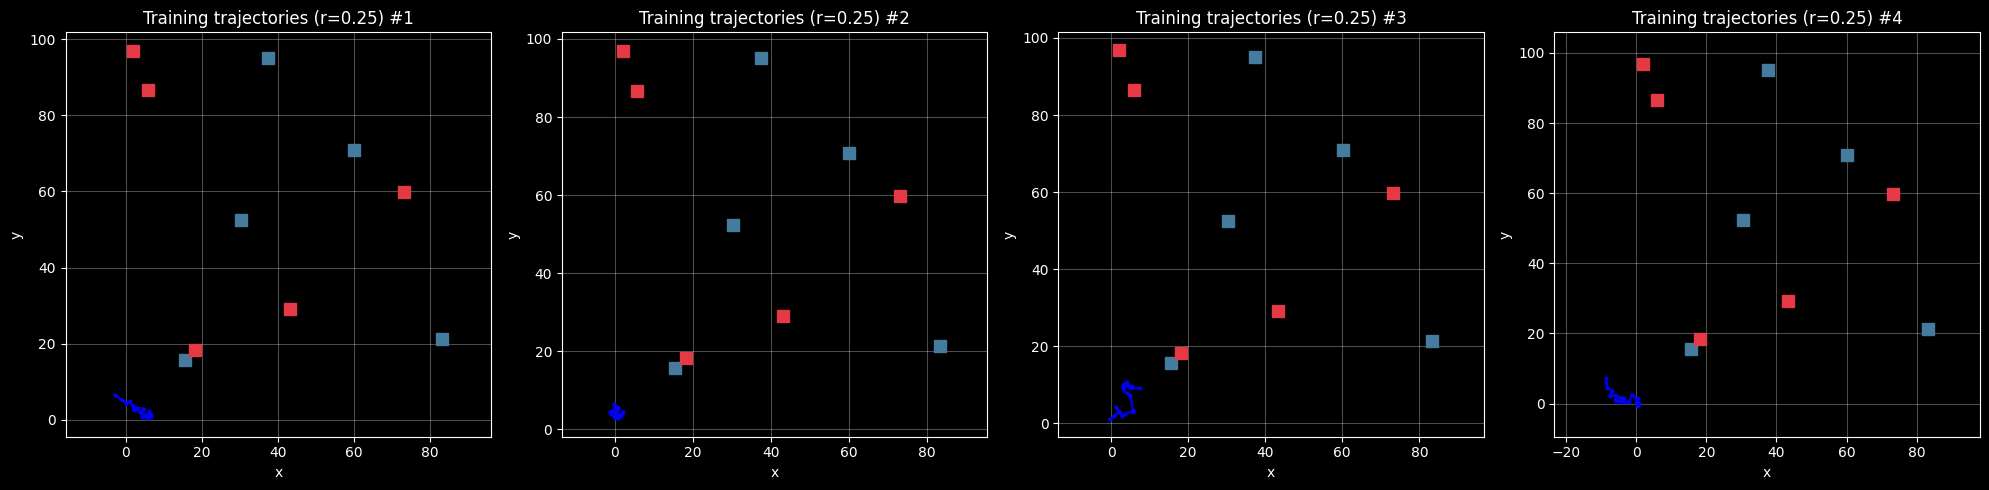

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /home/kfir-goldring/PycharmProjects/distributedKNET/models/const_vel_scenario_configured/const_vel_scenario_r=0.25/0 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/pytorch_lightning/c

┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gkf  │ GraphKalmanFilter │  262 K │ train │     0 │
│ 1 │ loss │ MSELoss           │      0 │ train │     0 │
└───┴──────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 262 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 262 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/lib/python3/dist-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/
_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/co
nnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/co
nnectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve 
performance.

/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1449
: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be 
compacted at every call, possibly greatly increasing memory usage. To compact weights again call 
flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(

Metric val_loss:_epoch improved. New best score: 4.488
Metric val_loss:_epoch improved by 0.596 >= min_delta = 0.001. New best score: 3.892
Metric val_loss:_epoch improved by 0.078 >= min_delta = 0.001. New best score: 3.814
Metric val_loss:_epoch improved by 0.038 >= min_delta = 0.001. New best score: 3.776
Metric val_loss:_epoch improved by 0.008 >= min_delta = 0.001. New best score: 3.767
Metric val_loss:_epoch improved by 0.005 >= min_delta = 0.001. New best score: 3.762
Metric val_loss:_epoch improved by 0.006 >= min_delta = 0.001. New best score: 3.756
Metric val_loss:_epoch improved by 0.024 >= min_delta = 0.001. New best score: 3.731
Metric val_loss:_epoch improved by 0.006 >= min_delta = 0.001. New best score: 3.725
Metric val_loss:_epoch improved by 0.016 >= min_delta = 0.001. New best score: 3.709
Metric val_loss:_epoch improved by 0.010 >= min_delta = 0.001. New best score: 3.699
Metric val_loss:_epoch improved by 0.004 >= min_delta = 0.001. New best score: 3.695


In [ ]:
# Reload local modules so notebook runs always use the latest Python code.
import utils.DistributedKalmanData as distributed_kalman_data_module
import utils.DistributedKalmanNet as distributed_kalman_net_module
import utils.ConstantVelocityScenario as constant_velocity_scenario_module

importlib.reload(distributed_kalman_data_module)
importlib.reload(distributed_kalman_net_module)
importlib.reload(constant_velocity_scenario_module)

from utils.DistributedKalmanData import GraphDataset
from utils.DistributedKalmanNet import GraphKalmanProcess
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    create_distance_based_graph,
    plot_generated_trajectories,
    plot_learning_curve,
    save_config,
)

seed_everything(config_val["seed"])

f_system = ConstantVelocityModel(time_delta)
h_system = DistanceAngleObservation(node_positions)
adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
node_types = h_system.node_classification[:, 0].cpu().numpy().astype(int)

model_dir = save_root / "DKN"
plot_dir = save_root / "plots"
config_dir = save_root / "configs"
for path in [model_dir, plot_dir, config_dir, log_root]:
    path.mkdir(parents=True, exist_ok=True)

print("Training node positions:")
print(node_positions)

name_suffix = "_shared_noise" if shared_noise_across_trajectories else ""

for r_noise in measurement_noise_values:
    run_name = f"const_vel_scenario_r={r_noise}{name_suffix}"
    curve_label = f"{r_noise}{name_suffix}"
    print(f"\nTraining model for measurement noise r = {curve_label}")
    r_array = r_noise * np.ones(num_nodes)

    train_dataset = GraphDataset(
        adjacency_matrix,
        f_system,
        h_system,
        process_noise_std,
        r_array,
        monte_carlo_simulations=config_val["train_sims"],
        time_steps=time_steps,
        n_expansions=1,
        x0=x0,
        state_dim=state_dimension,
        shared_noise_across_trajectories=shared_noise_across_trajectories,
    )
    val_dataset = GraphDataset(
        adjacency_matrix,
        f_system,
        h_system,
        process_noise_std,
        r_array,
        monte_carlo_simulations=config_val["val_sims"],
        time_steps=time_steps,
        n_expansions=1,
        x0=x0,
        state_dim=state_dimension,
        shared_noise_across_trajectories=shared_noise_across_trajectories,
    )

    sample_trajectories = [train_dataset[idx].y.cpu() for idx in range(min(config_val["preview_trajectories"], len(train_dataset)))]
    plot_generated_trajectories(
        node_positions,
        node_types,
        sample_trajectories,
        max_trajectories=config_val["preview_trajectories"],
        title_prefix=f"Training trajectories (r={curve_label})",
    )

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        batch_size=config_val["batch_size"],
        num_workers=0,
        pin_memory=False,
    )
    val_loader = DataLoader(
        val_dataset,
        shuffle=False,
        batch_size=config_val["batch_size"],
        num_workers=0,
        pin_memory=False,
    )

    kalman_process = GraphKalmanProcess(
        f_system,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=config_val["hidden_dim"],
        lr=config_val["learning_rate"],
        r_array=r_noise,
        learn_edge_kalman=config_val["learn_edge_kalman"],
        x0_scale=x0,
    ).to(torch.float32)

    logger = CSVLogger(str(log_root), name=run_name, version="0")
    early_stopping = pl.callbacks.EarlyStopping(
        monitor="val_loss:_epoch",
        patience=5,
        verbose=True,
        mode="min",
        min_delta=0.001,
    )
    trainer = pl.Trainer(
        max_epochs=config_val["max_epochs"],
        accelerator=trainer_accelerator,
        devices=1,
        logger=logger,
        log_every_n_steps=5,
        callbacks=[early_stopping],
        gradient_clip_val=1,
    )
    trainer.fit(kalman_process, train_loader, val_loader)

    model_path = model_dir / f"{run_name}.pth"
    config_path = config_dir / f"{run_name}.json"
    torch.save(kalman_process.state_dict(), model_path)

    run_config = dict(config_val)
    run_config["measurement_noise"] = float(r_noise)
    run_config["graph_type"] = "distance_based_graph"
    run_config["model_path"] = str(model_path)
    run_config["config_path"] = str(config_path)
    save_config(run_config, config_path)

    plot_learning_curve(logger.log_dir, curve_label, save_dir=str(plot_dir))

    sample_graph = val_dataset[0]
    with torch.no_grad():
        sample_prediction = kalman_process(sample_graph).squeeze().cpu().numpy().mean(axis=1)
    plot_dkn_prediction_sample(sample_graph, sample_prediction, node_positions, title=f"DKN validation example (r={curve_label})")

    print(f"Saved model: {model_path}")
    print(f"Saved config: {config_path}")

## Later Load Example

Use the JSON config saved next to each weight file to reconstruct the scenario settings when loading a trained model later.

In [ ]:
example_r = measurement_noise_values[0]
example_suffix = "_shared_noise" if shared_noise_across_trajectories else ""
example_run_name = f"const_vel_scenario_r={example_r}{example_suffix}"
example_config_path = save_root / "configs" / f"{example_run_name}.json"
example_model_path = save_root / "DKN" / f"{example_run_name}.pth"

print(f"Example config path: {example_config_path}")
print(f"Example model path:  {example_model_path}")

# Later, you can read the JSON config and rebuild the same graph/scenario before loading the weights.